In [48]:
import pandas as pd
import numpy as np

In [49]:
df = pd.read_csv("powerplant_data.csv")

In [50]:
df.head()

,AT,V,AP,RH,PE
0,8.34,40.77,1010.84,90.01,480.48
1,23.64,58.49,1011.40,74.20,445.75
2,29.74,56.90,1007.15,41.91,438.76
3,19.07,49.69,1007.22,76.79,453.09
4,11.80,40.66,1017.13,97.20,464.43


In [51]:
# AT => temperature
# V => Vacuum
# AP => pressure
# RH => humidity

#PE => produced energy 

In [52]:
df.isnull().sum()

AT    0
V     0
AP    0
RH    0
PE    0
dtype: int64

In [53]:
X = df.drop("PE", axis=1)
y = df["PE"]

In [54]:
X.head()

,AT,V,AP,RH
0,8.34,40.77,1010.84,90.01
1,23.64,58.49,1011.40,74.20
2,29.74,56.90,1007.15,41.91
3,19.07,49.69,1007.22,76.79
4,11.80,40.66,1017.13,97.20


In [55]:
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test= train_test_split(
    X,y, test_size=0.2, random_state=42
)

In [56]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [57]:
import torch
import torch.nn as nn

X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train.values, dtype=torch.float32).view(-1,1)

X_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test.values, dtype=torch.float32).view(-1,1)

In [58]:
from torch.utils.data import TensorDataset, DataLoader

train_dataset = TensorDataset(X_train_tensor,y_train_tensor)
test_dataset = TensorDataset(X_test_tensor,y_test_tensor)

In [59]:
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32)

## Deep Learning

In [60]:
# Define our ANN model

class ANN(nn.Module):
    def __init__(self):
        super(ANN, self).__init__()
        self.model = nn.Sequential(
            # 1st hidden layer
            nn.Linear(X_train.shape[1],6),
            nn.ReLU(),
            # 2nd hidden layer
            nn.Linear(6,6),
            nn.ReLU(),
            # 3rd hidden layer
            nn.Linear(6,1)
       
        )

    def forward(self,x):
        return self.model(x)

In [61]:
import torch.optim as optim
model = ANN()

# Loss, Optimizer

criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters())

In [65]:
# Train the ANN
train_losses = []
val_losses = []

best_val_loss = float("inf")

epochs = 100

for epoch in range(epochs):
    model.train()
    running_loss = 0.0 # tot training loss for 1 epoch
    
    for xb, yb in train_loader:
        # xb = features of 1 batch
        # yb = labels of 1 batch
        optimizer.zero_grad()
        
        outputs = model(xb) # forward prop....predicted outputs for this batch
        loss = criterion(outputs, yb) # compute loss
        loss.backward() # back prop.. compute gradients
        optimizer.step() # params update
        
        running_loss += loss.item() # loss is a tensor => py float

    epoch_train_loss = running_loss / len(train_loader)
    train_losses.append(epoch_train_loss)


    # Validation
    model.eval()
    running_val_loss = 0.0

    with torch.no_grad(): # no gradients compute
        for xb, yb in test_loader:
            outputs = model(xb)
            loss = criterion(outputs, yb)
            running_val_loss += loss

    epoch_val_loss = running_val_loss / len(test_loader)
    val_losses.append(epoch_val_loss)

    print(f"epoch {epoch+1}/{epochs} ==> train loss = {epoch_train_loss} & val loss = {epoch_val_loss}")

    if epoch_val_loss < best_val_loss:
        best_val_loss = epoch_val_loss
        torch.save(model.state_dict(), "best_model.pt") #.pt or .pth

epoch 1/100 ==> train loss = 20.64444220860799 & val loss = 18.95770835876465
epoch 2/100 ==> train loss = 20.613813376426698 & val loss = 18.915019989013672
epoch 3/100 ==> train loss = 20.503161732355753 & val loss = 18.986474990844727
epoch 4/100 ==> train loss = 20.63831795056661 & val loss = 19.62093162536621
epoch 5/100 ==> train loss = 20.50831122001012 & val loss = 18.594026565551758
epoch 6/100 ==> train loss = 20.482395774126054 & val loss = 19.914409637451172
epoch 7/100 ==> train loss = 20.42156221071879 & val loss = 19.54590606689453
epoch 8/100 ==> train loss = 20.649944432576497 & val loss = 18.678119659423828
epoch 9/100 ==> train loss = 20.5094092686971 & val loss = 18.74785041809082
epoch 10/100 ==> train loss = 20.523460523287454 & val loss = 18.777414321899414
epoch 11/100 ==> train loss = 20.61827406088511 & val loss = 19.202131271362305
epoch 12/100 ==> train loss = 20.657712694009145 & val loss = 18.81389045715332
epoch 13/100 ==> train loss = 20.54735349416733 &

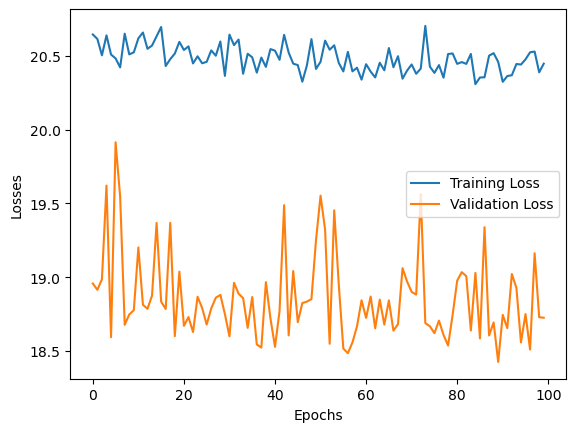

In [66]:
import matplotlib.pyplot as plt

loss_df = pd.DataFrame({
    "Training Loss": train_losses,
    "Validation Loss": val_losses
})

plt.plot(loss_df["Training Loss"], label = "Training Loss")
plt.plot(loss_df["Validation Loss"], label = "Validation Loss")

plt.xlabel("Epochs")
plt.ylabel("Losses")

plt.legend()

In [64]:
model.load_state_dict(torch.load("best_model.pt"))

<All keys matched successfully>

In [68]:
# Evaluate our Model

model.eval()
with torch.no_grad():
    train_preds = model(X_train_tensor)
    test_preds = model(X_test_tensor)

    train_mse_loss = criterion(train_preds, y_train_tensor)
    test_mse_loss = criterion(test_preds, y_test_tensor)
print("Training MSE: ", train_mse_loss.item())
print("Testing MSE: ", test_mse_loss.item())

Training MSE:  20.270673751831055
Testing MSE:  18.730222702026367


In [69]:
from sklearn.metrics import r2_score

print("r^2 score =", r2_score(y_test, test_preds))

r^2 score = 0.9345427137969868


In [70]:
predicted_df = pd.DataFrame(test_preds.numpy(), columns=["Predicted values"])
actual_df = pd.DataFrame(y_test.values, columns=["Actual Values"])

pd.concat([predicted_df, actual_df], axis=1)

,Predicted values,Actual Values
0,434.730743,433.27
1,436.384247,438.16
2,462.147461,458.42
3,477.592194,480.82
4,434.900696,441.41
...,...,...
1909,451.554169,456.70
1910,430.976379,438.04
1911,468.177338,467.80
1912,430.335358,437.14
